In [95]:
import pandas as pd

In [168]:
# import dataset in csv format
df = pd.read_csv("Country.csv")

In [169]:
# Show dataframe with head function.
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [170]:
# Show data types, shape columns with the help of function 
df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [99]:
df.shape

(167, 10)

In [100]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [101]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [171]:
# data divided in to to variables x & y (x in features & y in result)
x = df.drop(columns="country")
y= df['country']

In [103]:
x

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [172]:
# import data visualization library to see a data in different plots.
import matplotlib.pyplot as plt
import seaborn as sns

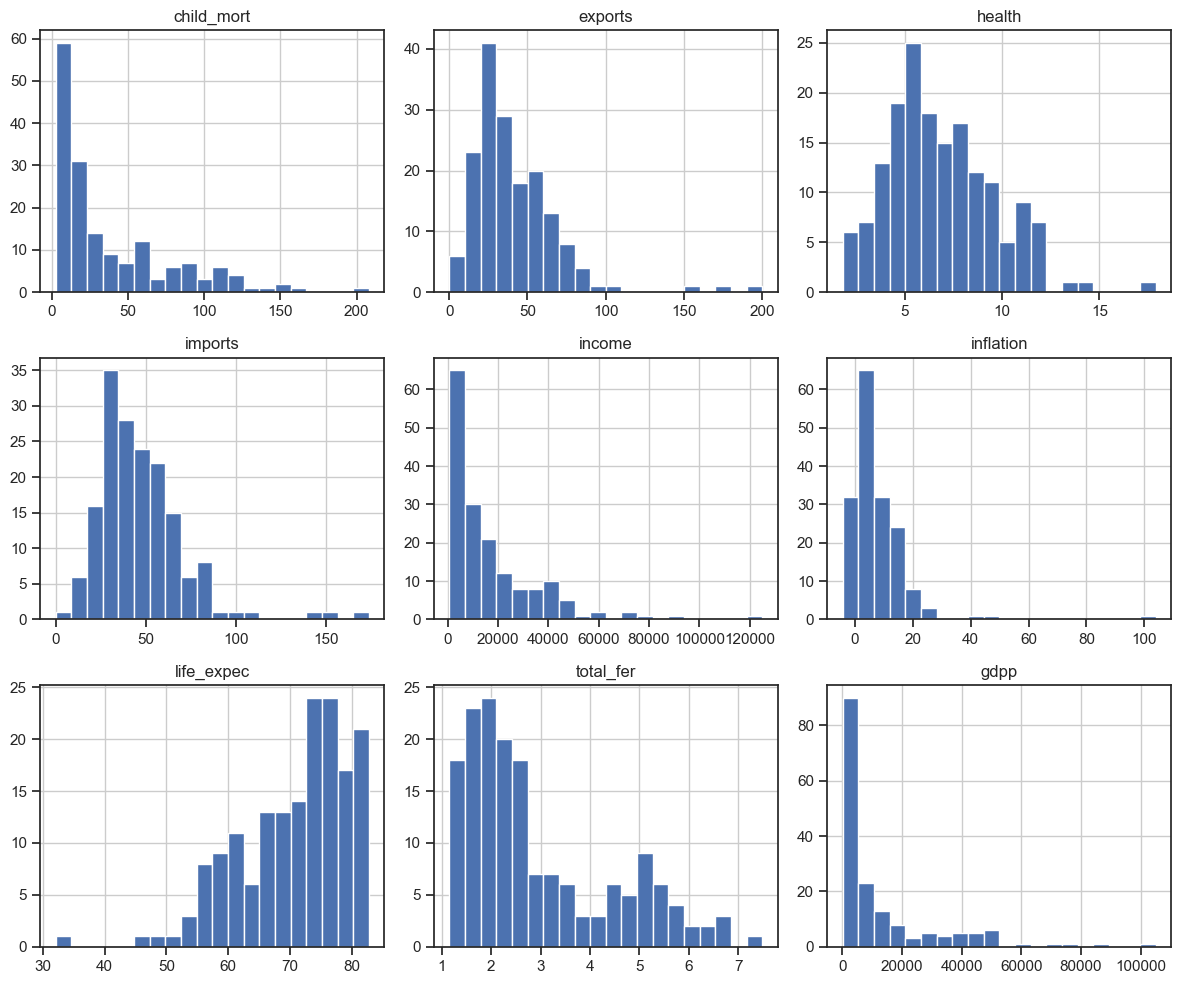

In [181]:
x.hist(
    figsize=(12,10),
    bins=20
)

plt.tight_layout()
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x158e9ebf250>,
 'caps': [<matplotlib.lines.Line2D at 0x158e9ebf4d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x158e9ebf110>,
 'medians': [<matplotlib.lines.Line2D at 0x158e9ebf750>,
 'fliers': [<matplotlib.lines.Line2D at 0x158e9ebf890>,
 'means': []}

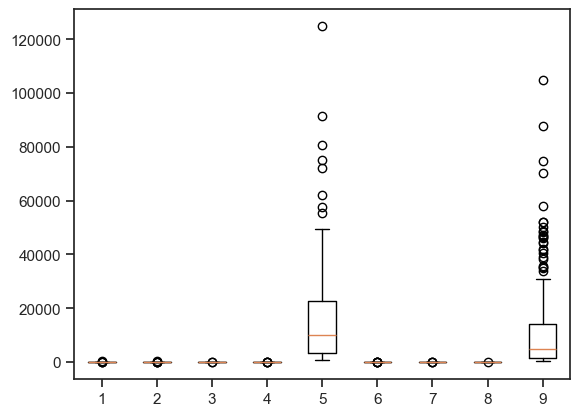

In [106]:
plt.boxplot(x)

In [173]:
# show the relation between features in data
x.corr()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


<Axes: >

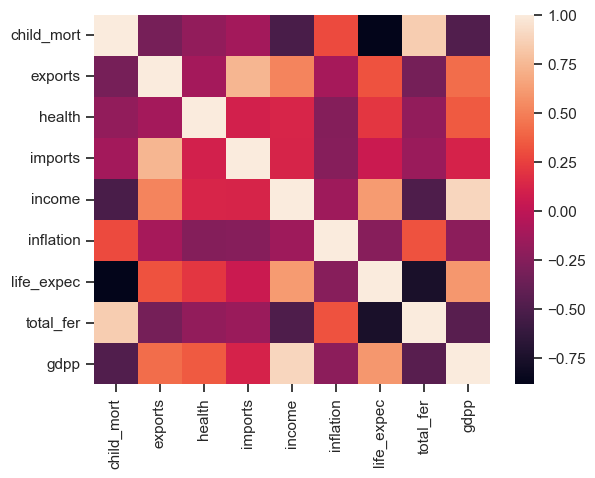

In [108]:
sns.heatmap(x.corr())

In [175]:
# import library for scaling the data columns scale between 0-1 & also fit and transform scaled data. 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [176]:
scaler = StandardScaler()

In [177]:
x_scaled = scaler.fit_transform(x)

<Axes: >

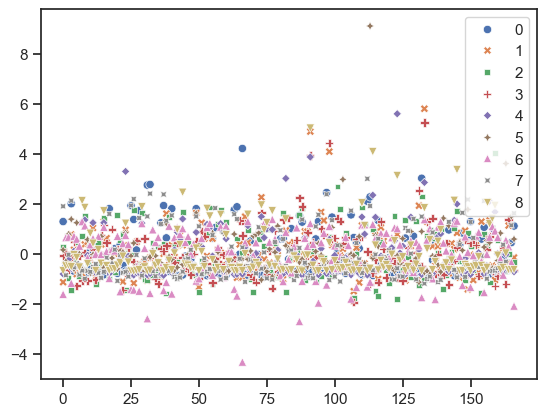

In [178]:
sns.scatterplot(x_scaled)

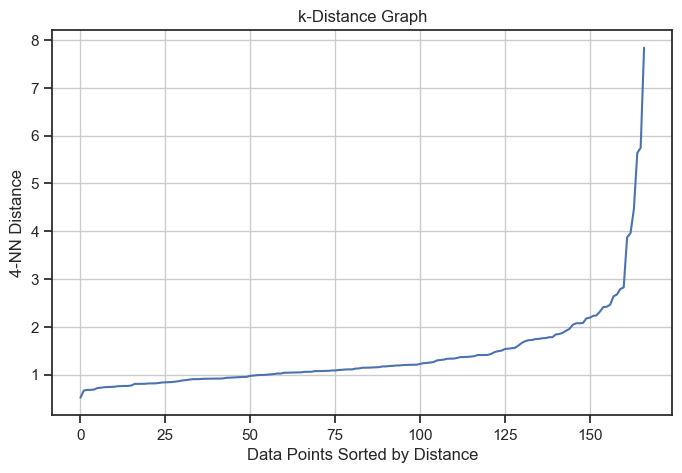

In [113]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.metrics import silhouette_score

# Assuming X_scaled contains the normalized dataset

min_samples = 5
k = min_samples - 1

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(x_scaled)

distances, indices = neighbors_fit.kneighbors(x_scaled)

# Sort distances
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.xlabel("Data Points Sorted by Distance")
plt.ylabel(f"{k}-NN Distance")
plt.title("k-Distance Graph")
plt.grid(True)
plt.show()

In [118]:
eps = 1

In [119]:
eps_values = [0.8, 1.0, 1.2]
min_samples_values = [4, 5, 6]

In [123]:
results = []

eps_values = [0.8, 1.0, 1.2]
min_samples_values = [4, 5, 6]

for eps in eps_values:
    for min_samp in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samp
        )

        labels = dbscan.fit_predict(x_scaled)

        # Number of clusters
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Number of noise points
        noise_points = np.sum(labels == -1)

        # Silhouette Score
        if n_clusters > 1:
            score = silhouette_score(x_scaled, labels)
        else:
            score = np.nan

        results.append([
            eps,
            min_samp,
            n_clusters,
            noise_points,
            score
        ])
results_df = pd.DataFrame(
    results,
    columns=[
        'eps',
        'min_samples',
        'Clusters',
        'Noise Points',
        'Silhouette Score'
    ]
)

print(results_df)

   eps  min_samples  Clusters  Noise Points  Silhouette Score
0  0.8            4         5           134         -0.206452
1  0.8            5         3           146         -0.245355
2  0.8            6         1           158               NaN
3  1.0            4         4            84         -0.031864
4  1.0            5         3            94         -0.024819
5  1.0            6         2           113          0.009157
6  1.2            4         3            50          0.148793
7  1.2            5         3            53          0.148443
8  1.2            6         3            63          0.107031


In [179]:
## find out the best silhouette score where the;
print("eps= 1.2")
print ("min_sample = 4")
print ("silhouette_Score = 0.1487")

eps= 1.2
min_sample = 4
silhouette_Score = 0.1487


Among all tested parameter combinations, eps = 1.2 and min_samples = 4 achieved the highest Silhouette Score (0.149), produced three meaningful clusters, and reduced the number of noise points to 50. Therefore, this combination was selected as the optimal DBSCAN configuration.

In [180]:

dbscan = DBSCAN(eps=1.2, min_samples=4)

labels = dbscan.fit_predict(x_scaled)

df['Cluster'] = labels

In [134]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_points = sum(labels == -1)

print("Total Clusters:", n_clusters)
print("Total Noise Points:", noise_points)

Total Clusters: 3
Total Noise Points: 50


In [136]:
for cluster in sorted(df['Cluster'].unique()):
    
    if cluster != -1:
        print(f"\nCluster {cluster}")
        print(df[df['Cluster'] == cluster]['country'].tolist())


Cluster 0
['Afghanistan', 'Benin', 'Burkina Faso', 'Cameroon', 'Chad', 'Comoros', "Cote d'Ivoire", 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lao', 'Madagascar', 'Malawi', 'Mali', 'Mozambique', 'Niger', 'Senegal', 'Tanzania', 'Uganda', 'Yemen', 'Zambia']

Cluster 1
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Cambodia', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Fiji', 'Georgia', 'Grenada', 'Guatemala', 'Guyana', 'Hungary', 'India', 'Indonesia', 'Iran', 'Jamaica', 'Kazakhstan', 'Kyrgyz Republic', 'Latvia', 'Lebanon', 'Lithuania', 'Macedonia, FYR', 'Malaysia', 'Maldives', 'Mauritius', 'Montenegro', 'Morocco', 'Namibia', 'Nepal', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Rom

In [137]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         child_mort    exports     health    imports        income  inflation  \
Cluster                                                                         
-1        51.172000  51.650380   6.810000  55.237318  23299.420000  12.767420   
 0        94.186957  25.465217   5.604783  39.073913   2039.217391   7.856739   
 1        20.935526  40.206316   6.391711  46.700000  12884.078947   5.999132   
 2         4.172222  35.627778  10.168889  34.494444  37338.888889   1.364222   

         life_expec  total_fer          gdpp  
Cluster                                       
-1        67.938000   3.407800  16799.400000  
 0        59.395652   5.342609    811.739130  
 1        73.178947   2.193421   7443.078947  
 2        81.011111   1.796667  41150.000000  


In [139]:
outliers = df[df['Cluster'] == -1]['country'].tolist()

print("Outlier Countries:")
print(outliers)

Outlier Countries:
['Angola', 'Bahrain', 'Belarus', 'Belgium', 'Brunei', 'Burundi', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Jordan', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Libya', 'Luxembourg', 'Malta', 'Mauritania', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Myanmar', 'Nigeria', 'Norway', 'Oman', 'Pakistan', 'Qatar', 'Rwanda', 'Saudi Arabia', 'Seychelles', 'Sierra Leone', 'Singapore', 'Solomon Islands', 'South Africa', 'Sudan', 'Switzerland', 'Timor-Leste', 'Togo', 'Tonga', 'Turkmenistan', 'United Arab Emirates', 'United States', 'Venezuela', 'Vietnam']


In [141]:
outlier_df = df[df['Cluster'] == -1]
print(outlier_df[['country']])

                      country
3                      Angola
11                    Bahrain
14                    Belarus
15                    Belgium
23                     Brunei
26                    Burundi
31   Central African Republic
37           Congo, Dem. Rep.
38                Congo, Rep.
49          Equatorial Guinea
50                    Eritrea
55                      Gabon
66                      Haiti
72                       Iraq
73                    Ireland
78                     Jordan
81                   Kiribati
82                     Kuwait
87                    Lesotho
88                    Liberia
89                      Libya
91                 Luxembourg
98                      Malta
99                 Mauritania
101     Micronesia, Fed. Sts.
102                   Moldova
103                  Mongolia
107                   Myanmar
113                   Nigeria
114                    Norway
115                      Oman
116                  Pakistan
123       

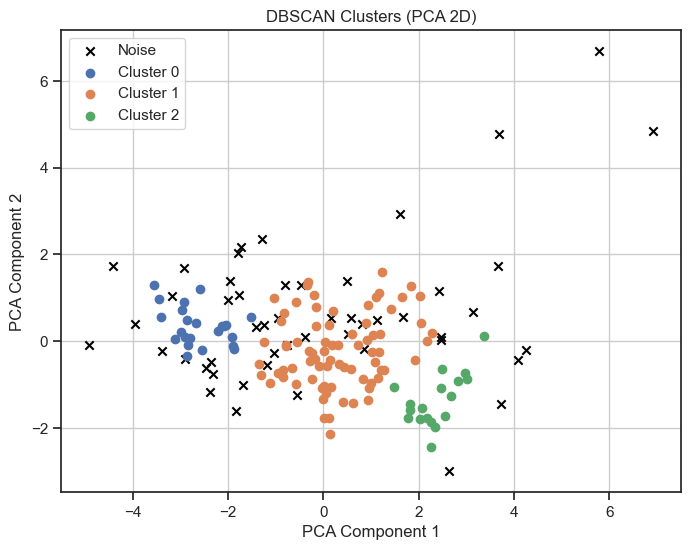

In [182]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(x_scaled)

df['PCA1'] = components[:, 0]
df['PCA2'] = components[:, 1]

plt.figure(figsize=(8,6))

# plot clusters
for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]
    
    if cluster == -1:
        plt.scatter(subset['PCA1'], subset['PCA2'], 
                    c='black', marker='x', label='Noise')
    else:
        plt.scatter(subset['PCA1'], subset['PCA2'], 
                    label=f'Cluster {cluster}')

plt.title("DBSCAN Clusters (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid()
plt.show()

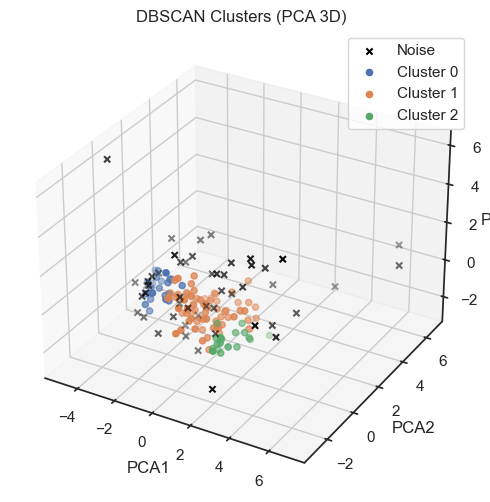

In [161]:
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
components = pca.fit_transform(x_scaled)

df['PCA1'] = components[:, 0]
df['PCA2'] = components[:, 1]
df['PCA3'] = components[:, 2]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]
    
    if cluster == -1:
        ax.scatter(subset['PCA1'], subset['PCA2'], subset['PCA3'],
                   c='black', marker='x', label='Noise')
    else:
        ax.scatter(subset['PCA1'], subset['PCA2'], subset['PCA3'],
                   label=f'Cluster {cluster}')

ax.set_title("DBSCAN Clusters (PCA 3D)")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.legend()
plt.show()

In [162]:
import pandas as pd

cluster_means = df.groupby('Cluster')[['gdpp', 'child_mort', 'income']].mean()
print(cluster_means)

                 gdpp  child_mort        income
Cluster                                        
-1       16799.400000   51.172000  23299.420000
 0         811.739130   94.186957   2039.217391
 1        7443.078947   20.935526  12884.078947
 2       41150.000000    4.172222  37338.888889


C:\Users\Lenevo\AppData\Local\Temp\ipykernel_2556\4169860332.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


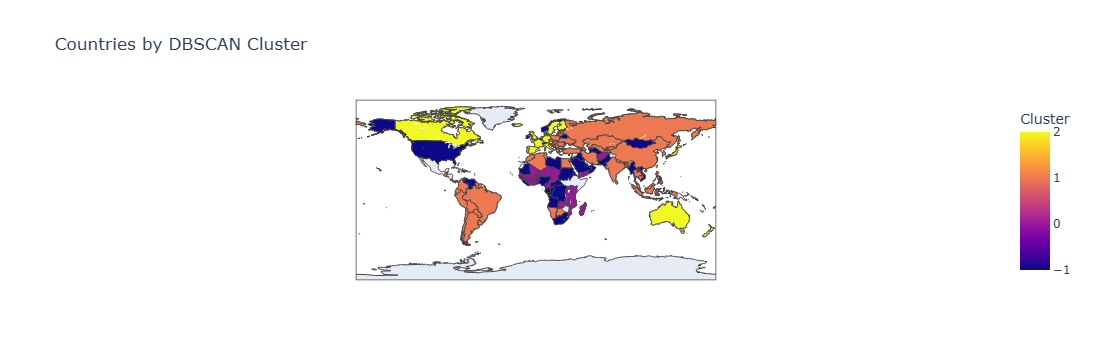

In [164]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="country",
    locationmode="country names",
    color="Cluster",
    title="Countries by DBSCAN Cluster"
)

fig.show()

## PCA Visualization
PCA reduced dataset to 2D and 3D for visualization.
Clusters are visually separable in PCA space.
Noise points appear as black crosses.

## Cluster Insights
Cluster 0 → Low income / high mortality countries
Cluster 1 → Middle development countries
Cluster 2 → High income / developed countries


## Key Observation

DBSCAN successfully identified meaningful clusters and outliers in the dataset. PCA visualization confirms cluster separation, while noise points represent extreme socio-economic cases.